# Null models and permutation testing

We touched on null models briefly in [Notebook 1](intro01_spatial_colocalizations.ipynb) (conceptual background) and [Notebook 2](intro02_nispace_intro.ipynb) (where we called `permute("maps")` without much explanation). This notebook explains what's happening under the hood and when to use which approach.

There are two fundamentally different situations that call for different null models:

1. **You have a single group-level map** (e.g., the pain NeuroQuery map, a published effect size): permute the *reference maps*.
2. **You have individual subject data and a group design** (e.g., the anorexia nervosa dataset): permute the *group labels*.

For X-Set Enrichment Analysis, there's a third type — we'll cover that in [Notebook 10](intro10_xsea.ipynb).

In [2]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from nispace.datasets import fetch_reference, fetch_example
from nispace.io import load_img
from nispace.api import NiSpace

# set up with the pain map
pet_maps = fetch_reference("pet", parcellation="Yan200",
                           collection="UniqueTracers", print_references=False)
pain_map = load_img("neuroquery/pain.nii.gz")

nsp = NiSpace(x=pet_maps, y=pain_map, y_labels="Pain",
              parcellation="Yan200", seed=42, n_proc=4)
nsp.fit()
nsp.colocalize("spearman")

INFO | 13/07/26 14:58:26 | nispace.datasets: Loading pet maps.


INFO | 13/07/26 14:58:26 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 13/07/26 14:58:26 | nispace.datasets: Filtering maps by collection.


INFO | 13/07/26 14:58:26 | nispace.datasets: Loading data parcellated with 'Yan200'


INFO | 13/07/26 14:58:26 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


...

INFO | 13/07/26 14:58:31 | nispace.api: Z-standardizing 'X' data.


INFO | 13/07/26 14:58:31 | nispace.api: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***


INFO | 13/07/26 14:58:31 | nispace.api: Running 'spearman' colocalization.


INFO | 13/07/26 14:58:31 | nispace.api: Pre-ranking X and Y data.


Colocalizing (spearman, 4 proc): 100%|██████████████████████████████████████████████████████| 1/1 [00:00<00:00, 2519.10it/s]

## Part 1: Surrogate map null models

When you call `permute("maps")`, NiSpace generates spatially-constrained random versions of the reference maps and recomputes the correlation with your input map for each permutation. The empirical distribution of these null correlations becomes the null distribution.

The null method is **auto-selected** based on the parcellation type — you can customize this, but usually should not need to.

- **Cortical-only parcellations** with a surface space (fsLR, fsaverage): the `"cornblath"` fractional-transition spin test is chosen automatically (`"spin"` is an alias)
- **Combined (cortex + subcortex) parcellations**: Moran spectral randomization (`"moran"`) on the full combined distance matrix
- **Volumetric-only parcellations**: Moran spectral randomization (`"moran"`) is chosen automatically

Several methods are available (more are continuously added):

| Method | Key idea | When selected |
|--------|----------|---------------|
| `"cornblath"` / `"spin"` | Fractional transition spin: for each rotation, the null map value at parcel *i* is a weighted average over all parcels that received its vertices. | **Auto-default** for cortical-only parcellations |
| `"baum"` | Vertex-level rotation + modal parcel assignment | Alternative spin; explicit choice |
| `"alexander_bloch"` | Original nearest-centroid spin (Alexander-Bloch et al. 2018) | Alternative spin; explicit choice |
| `"vasa"` | As in the Alexander-Bloch method, but exact reassignments instead of nearest-centroid | Alternative spin; explicit choice |
| `"hungarian"` | As in the Alexander-Bloch method, but hungarian matching instead of nearest-centroid | Alternative spin; explicit choice |
| `"moran"` / `"brainspace"` | Moran spectral randomization: Randomize spectral coefficients of the spatial covariance | **Auto-default** for subcortex, volumetric, and combined parcellations |
| `"burt2020"` / `"brainsmash"` / `"variogram"` | Auto-regressive model to match data-distance relationship | Explicit choice; any parcellation |
| `"burt2018"` | Match the spatial variogram of the original map | Explicit choice; any parcellation |

Yan200 is a cortical-only atlas with fsLR available, so the cornblath spin test is selected automatically when we omit `null_method`.

### The spin test (cornblath)

The spin test works by projecting the cortical parcellation onto a sphere and applying random rotations. This preserves the spatial topology of the original map while breaking any specific spatial relationship with the input map.

NiSpace's default spin method is `"cornblath"` (Cornblath et al., 2020), as recommended by [Markello & Misic (2021)](https://markello-spatialnulls.netlify.app/recommendations). The original method projects parcellated data back to the surface, spins the surface, and basically re-parcellates the spun map using the original parcellation – each new parcel value will then be the average of multiple original parcel values, weighted by the number of vertices that landed in the new parcel.  
We implement the method in an alternative form: we estimate a **fractional transition matrix**: for each random rotation, it records what fraction of each parcel's surface vertices land in each other parcel. The null map value for parcel *i* is then a weighted average over all parcels that received its vertices. This implementation has the big advantage that the transition matrices can be stored and re-applied. For all included cortical parcellations, NiSpace automatically downloads 10,000 of these matrices, which reduces computation time of Cornblath nulls to a few seconds. The alias `"spin"` maps to `"cornblath"` — they are identical.

In [4]:
# spin test — auto-selected for Yan200 (cortical + fsLR), so null_method can be omitted
nsp.permute("maps", n_perm=1000, p_tails="upper")
p_spin = nsp.get_p_values()
print("Spin test — 5 lowest p-values:")
p_spin.T.sort_values(by="Pain").head(5)

INFO | 13/07/26 14:58:34 | nispace.api: *** NiSpace.permute() - Estimate exact non-parametric p values. ***


INFO | 13/07/26 14:58:34 | nispace.api: Permutation of: X maps.


INFO | 13/07/26 14:58:34 | nispace.api: Using default null method 'cornblath' (parcellation null space: 'fsLR').


INFO | 13/07/26 14:58:34 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


INFO | 13/07/26 14:58:34 | nispace.api: Loading observed colocalizations (method = 'spearman').


...

Processing null arrays (4 proc): 100%|█████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 878.93it/s]

Null colocalizations (spearman, 4 proc): 100%|████████████████████████████████████████| 1000/1000 [00:00<00:00, 7567.00it/s]

INFO | 13/07/26 14:58:40 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).


Spin test — 5 lowest p-values:


,,Pain
set,map,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.048
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.065
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.111
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.124
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.259


### Moran Spectral Randomization (moran)

Moran spectral randomization is automatically selected when the spin test is not applicable — specifically for **combined (cortex + subcortex)** or **volumetric-only** parcellations that have no spherical surface projection.

It works by decomposing the spatial covariance structure of the parcellation into eigenvectors (Moran eigenvectors), then randomizing the spectral coefficients while preserving the overall structure. The result is a null map with the same degree of spatial autocorrelation, but with the specific spatial pattern scrambled.

Two key properties:
1. **Works with any parcellation geometry** — subcortical structures, volumetric atlases, anything.
2. **No precomputed matrix needed** — eigenvectors are derived on the fly from the parcellation distance matrix.

With Yan200 the spin test is the auto-selected default, so to run Moran we specify `maps_method="moran"` explicitly:

In [5]:
nsp.permute("maps", maps_method="moran", n_perm=1000, p_tails="upper")
p_moran = nsp.get_p_values()
print("Moran spectral — 5 lowest p-values:")
p_moran.T.sort_values(by="Pain").head(5)

INFO | 13/07/26 14:58:40 | nispace.core.permute: Found existing null maps.


WARNING | 13/07/26 14:58:40 | nispace.core.permute: Null method changed. Will re-generate.


INFO | 13/07/26 14:58:40 | nispace.core.permute: Generating null maps (n = 1000, null_method = 'moran').


INFO | 13/07/26 14:58:40 | nispace.nulls: Null map generation: Assuming n = 29 data vector(s) for n = 200 parcels.


INFO | 13/07/26 14:58:40 | nispace.nulls: Using provided distance matrix/matrices.


...

Processing null arrays (4 proc): 100%|████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 6292.21it/s]

Null colocalizations (spearman, 4 proc): 100%|███████████████████████████████████████| 1000/1000 [00:00<00:00, 11888.21it/s]

INFO | 13/07/26 14:58:42 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).


Moran spectral — 5 lowest p-values:


,,Pain
set,map,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.059
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.101
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.121
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.179
Opioids/Endocannabinoids,target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020,0.258


In [6]:
# compare spin and Moran side by side
comparison = pd.DataFrame({
    "rho": nsp.get_colocalizations().T["Pain"],
    "p_spin": p_spin.T["Pain"],
    "p_moran": p_moran.T["Pain"],
}).sort_values("p_spin")
comparison.head(10)

,,rho,p_spin,p_moran
set,map,,,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.422783,0.048,0.059
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.335397,0.065,0.101
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.288889,0.111,0.267
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.273213,0.124,0.121
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.180214,0.259,0.179
Opioids/Endocannabinoids,target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020,0.171576,0.263,0.258
Serotonin,target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012,0.145715,0.280,0.309
Dopamine,target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018,0.097589,0.345,0.327
GABA,target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022,0.107938,0.358,0.365


### Combined parcellations: Moran on the full distance matrix

For combined (cortex + subcortex) parcellations, the spin test cannot cover the whole brain — subcortical structures have no spherical surface projection. NiSpace's default is therefore **Moran spectral randomization (`"moran"`)** on the **full combined distance matrix** (cortex + subcortex together), treating the whole parcellation as a single spatial region.

**On cortex-subcortex split methods and cortex-subcortex gradients.** We allow for cortex-subcortex split methods like `("moran", "moran")` or `("spin", "moran")` if the used parcellation is an internal combiuned one (e.g., `("Yan200", "TianS2")`). This setup will use the first model for the cortical, and the second model for the subcortical component. This has two advantages: First, the cortex is indeed organized as a surface, so one could argue that the more biologically correct null model is a spin test. The combined null model setup can use spin tests as far as possible (i.e., for the cortex) and a volumetric distance-based null model for the rest (i.e., the subcortex). Second, many reference or input maps have a cortical-subcortical gradient. This broad gradient can induce spatial correlations that may not be of interest. A single null method, e.g. `"moran"` on the whole brain distance matrix will largely retain the value distribution of the observed map in the nulls, but the cortex-subcortex gradient will get lost. Generating nulls separately for cortex and subcortex will retain the value distributions within each of those and therefore largely retain the whole-brain gradient. The trade-off is that the spin-generated null maps tend to make the overall test **more conservative** — you may see fewer significant results. We therefore keep the one-shot null method `"moran"` for whole-brain (combined) parcellations and leave the split null option for the user to decide depending on their hypotheses:  
> Are you interested in spatial correlations beyond a cortex-subcortex gradient or is alignment between these gradients part of your hypothesis?

| `maps_method` | Notes |
|---------------|-------|
| `"moran"` | **Auto-default** for combined parcellations; runs on full combined dist_mat |
| `("cornblath", "moran")` | Split: spin for cortex, Moran for subcortex; explicit choice |
| `("baum", "moran")` | Alternative spin for cortex |
| `("alexander_bloch", "moran")` | Legacy spin variant |
| `("cornblath", "burt2020")` | Variogram for subcortex |
| `"burt2020"` | BrainSmash variogram on full combined dist_mat |
| `"burt2018"` | Burt 2018 method on full combined dist_mat |

The subcortex position of split methods only accepts non-spin options (`"moran"`, `"burt2020"`, `"burt2018"`).



In [7]:
from nispace.datasets import fetch_reference as _fr

# load PET maps for combined parcellation
pet_combined = _fr("pet", parcellation="Yan200+TianS1",
                   collection="UniqueTracers", print_references=False)

nsp_combined = NiSpace(x=pet_combined, y=pain_map, y_labels="Pain",
                       parcellation="Yan200+TianS1", seed=42, n_proc=4)
nsp_combined.fit()
nsp_combined.colocalize("spearman")

# auto-selects "moran" on the full combined dist_mat (cx+sc together)
nsp_combined.permute("maps", n_perm=500, p_tails="upper")
p_combined = nsp_combined.get_p_values()
print("Combined parcellation (moran, default) — 5 lowest p-values:")
p_combined.T.sort_values(by="Pain").head(5)

INFO | 13/07/26 14:58:42 | nispace.datasets: Loading pet maps.


INFO | 13/07/26 14:58:42 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 13/07/26 14:58:42 | nispace.datasets: Filtering maps by collection.


INFO | 13/07/26 14:58:42 | nispace.datasets: Loading and inner-merging data parcellated with 'Yan200' and 'TianS1'


INFO | 13/07/26 14:58:42 | nispace.core.parcellation: Building combined Parcellation 'Yan200+TianS1' from library.


...

Processing null arrays (4 proc): 100%|██████████████████████████████████████████████████| 500/500 [00:00<00:00, 2889.05it/s]

Null colocalizations (spearman, 4 proc): 100%|██████████████████████████████████████████| 500/500 [00:00<00:00, 6024.83it/s]

INFO | 13/07/26 14:59:02 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).


Combined parcellation (moran, default) — 5 lowest p-values:


,,Pain
set,map,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.006
Opioids/Endocannabinoids,target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020,0.138
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.148
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.168
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.208


## Part 2: Group permutation

When you have individual subject data and a group comparison design, permuting the reference maps isn't quite right — you should permute the group labels instead. The logic is:

> If the colocalization between the patient effect size map and a reference map is real, then randomly reassigning subjects to groups should produce smaller effect sizes, and hence smaller colocalizations.

This is implemented with `permute("groups")`. We use the anorexia nervosa example dataset below.

> **Note:** This dataset is **simulated** and not intended for scientific use.

In [8]:
# set up with the anorexia nervosa dataset
an_data = fetch_example("anorexianervosa", parcellation="Yan200")
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

nsp_groups = NiSpace(x=pet_maps, y=an_data, parcellation="Yan200",
                     seed=42, n_proc=4)
nsp_groups.fit()

# compute effect sizes first
nsp_groups.transform_y(transform="hedges(a,b)", groups=groups)
nsp_groups.colocalize("spearman")

# group permutation: randomly shuffle the AN/HC labels and recompute
nsp_groups.permute(
    "groups",
    groups=groups,
    n_perm=1000, # increase to >=10000 for final analyses
    p_tails="two"  # two-tailed: we don't have a directional hypothesis here
)
p_groups = nsp_groups.get_p_values()
y_label = p_groups.index[0]
print(f"Group permutation ({y_label}) — 5 lowest p-values:")
p_groups.T.sort_values(by=y_label).head(5)

INFO | 13/07/26 14:59:02 | nispace.datasets: Loading example dataset: 'anorexianervosa', parcellated with: Yan200.


INFO | 13/07/26 14:59:02 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 13/07/26 14:59:02 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 13/07/26 14:59:02 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 13/07/26 14:59:02 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


...

/Applications/miniforge3/envs/nsp309/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Null colocalizations (spearman, 4 proc): 100%|████████████████████████████████████████| 1000/1000 [00:00<00:00, 2097.71it/s]

INFO | 13/07/26 14:59:04 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


Group permutation (hedges) — 5 lowest p-values:


hedges
set       map                                                       
Serotonin target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa...   0.001
Dopamine  target-D23_tracer-flb457_n-55_dx-hc_pub-sandieg...   0.001
          target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...   0.002
Serotonin target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012     0.006
GABA      target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu...   0.014

### Which null model should I use?

A practical guide:

| Situation | Recommended null model |
|-----------|------------------------|
| Single cortical map (published effect size, meta-analytic map) | `permute("maps")` — `"cornblath"` spin auto-selected for cortical atlases (e.g., Yan200) |
| Single map with combined (cx+sc) parcellation | `permute("maps")` — `"moran"` auto-selected (full combined dist_mat) |
| Single map with volumetric-only parcellation | `permute("maps")` — `"moran"` auto-selected |
| Individual subject data with group comparison | `permute("groups")` |
| XSEA (set enrichment) | `permute("maps")` by default — see [Notebook 10](intro10_xsea.ipynb) |

Group permutation is more computationally expensive (the effect size must be recomputed for each permutation) but is more appropriate when you have individual-level data.

## Part 3: Visualizing the null distribution

After calling `permute()`, the null distribution is stored internally and used when you call `nsp.plot()`. The grey shading in the plot represents the null distribution percentiles.

INFO | 13/07/26 14:59:04 | nispace.plotting: Significance annotation: 0/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


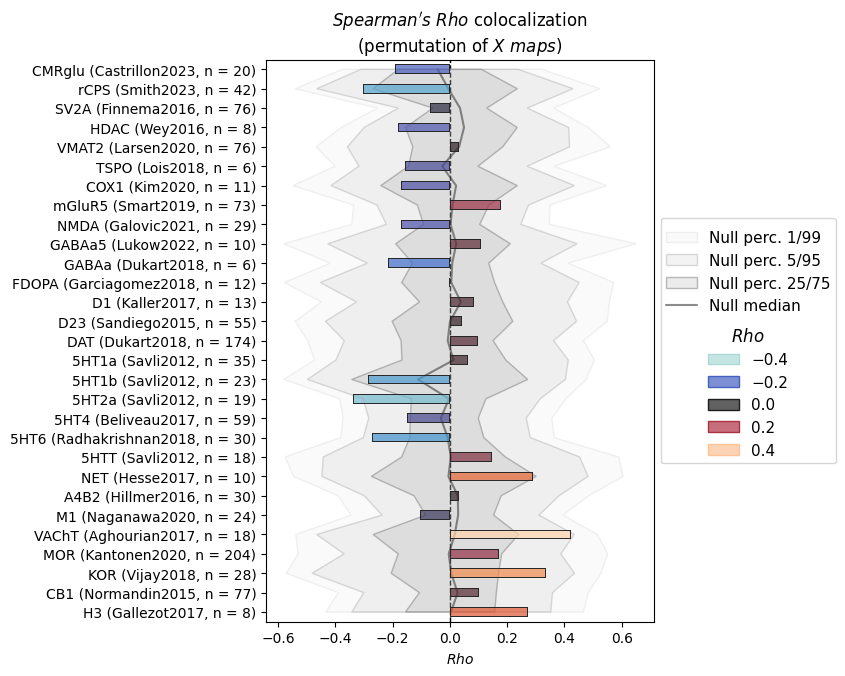

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x333148160>)

In [9]:
# correct p values
nsp.correct_p()
# plot with null distribution shading
nsp.plot()

## Summary

- `permute("maps")` without specifying `null_method` — auto-selects `"cornblath"` for cortical-only parcellations with a surface space, `"moran"` for combined (cx+sc) and volumetric-only parcellations
- `permute("maps", null_method="cornblath")` — fractional transition spin (default for cortical parcellations); alias: `"spin"`
- `permute("maps", null_method="baum")` — modal parcel assignment spin; alternative to cornblath
- `permute("maps", null_method="alexander_bloch")` — original nearest-centroid spin; legacy
- `permute("maps", null_method="moran")` — Moran spectral; auto-default for combined and volumetric parcellations, or explicit override
- `permute("maps", null_method="burt2020")` — variogram matching; works with any parcellation
- `permute("maps", null_method=("cornblath", "moran"))` — explicit split for combined parcellations (cx=cornblath, sc=moran); accounts for cx-sc gradients but may be more conservative
- `permute("groups", groups=...)` — group label permutation; preferred for individual subject data
- All methods produce empirical p-values stored in the NiSpace object, retrievable with `get_p_values()`

Next: [Notebook 6](intro06_multiple_comparisons.ipynb) covers multiple comparisons correction — because running 29 receptor tests at once without correction is not a great idea.